# USFS TreeMap 2022 Dataset Demo

TreeMap 2022 is a tree-level model of the forests of the conterminous United States circa 2022. It provides detailed spatial information on forest characteristics, including:
- Aboveground biomass and carbon storage
- Tree density and stand characteristics
- Forest type and size class
- Stand age and basal area

## 1. Setup and Authentication

In [1]:
import os
from dotenv import load_dotenv
from matplotlib import pyplot as plt
import numpy as np
import torch
import ee
from torchgeo.datasets import BoundingBox
from forestvision.datasets import GEETreeMap

In [2]:
# Load environment variables from .env file
load_dotenv("../.env")
gee_project = os.getenv("GEE_PROJECT_NAME")

# Authenticate and initialize Earth Engine
ee.Authenticate()
ee.Initialize(project=gee_project)

print(f"Successfully authenticated with project: {gee_project}")

Successfully authenticated with project: forestsegnet


## 2. Define Region of Interest

We'll define a bounding box in the Pacific Northwest (Oregon) where there is significant forest coverage.

In [3]:
# Define a bounding box for a forested region in Oregon
forest_roi = BoundingBox(
    -2219976.5070072114,  # minx (west)
    -2216076.5070072114,  # maxx (east)
    2650010.507788832,  # miny (south)
    2653910.507788832,  # maxy (north)
    0,  # mint (start time)
    0,  # maxt (end time)
)

print(f"ROI Bounds: {forest_roi}")
print(f"Width: {forest_roi.maxx - forest_roi.minx:.1f} meters")
print(f"Height: {forest_roi.maxy - forest_roi.miny:.1f} meters")

ROI Bounds: BoundingBox(minx=-2219976.5070072114, maxx=-2216076.5070072114, miny=2650010.507788832, maxy=2653910.507788832, mint=0, maxt=0)
Width: 3900.0 meters
Height: 3900.0 meters


## 3. Load TreeMap Dataset

The TreeMap dataset provides multiple forest characteristics. We'll start by loading the default bands (biomass and carbon).

In [4]:
# Create TreeMap dataset with default bands (ALST, BIOMASS, CARBON)
treemap = GEETreeMap(
    roi=forest_roi,
    res=30,
)

print("TreeMap Dataset Information:")
print(treemap)
print(f"\nDefault bands: {treemap.bands}")
print(f"All available bands: {treemap.all_bands}")
print(f"Spatial resolution: {treemap.res} meters")
print(f"No data value: {treemap.nodata}")

TreeMap Dataset Information:
GEETreeMap Dataset
    type: GeoDataset
    bbox: BoundingBox(minx=-2219976.5070072114, maxx=-2216076.5070072114, miny=2650010.507788832, maxy=2653910.507788832, mint=0.0, maxt=0.0)
    size: 1

Default bands: ['ALSTK', 'BALIVE', 'CANOPYPCT', 'CARBON_D', 'CARBON_DWN', 'CARBON_L', 'DRYBIO_D', 'DRYBIO_L', 'FLDSZCD', 'FLDTYPCD', 'FORTYPCD', 'GSSTK', 'QMD', 'SDIsum', 'STANDHT', 'STDSZCD', 'TM_ID', 'TPA_DEAD', 'TPA_LIVE', 'VOLBFNET_L', 'VOLCFNET_D', 'VOLCFNET_L']
All available bands: ['ALSTK', 'BALIVE', 'CANOPYPCT', 'CARBON_D', 'CARBON_DWN', 'CARBON_L', 'DRYBIO_D', 'DRYBIO_L', 'FLDSZCD', 'FLDTYPCD', 'FORTYPCD', 'GSSTK', 'QMD', 'SDIsum', 'STANDHT', 'STDSZCD', 'TM_ID', 'TPA_DEAD', 'TPA_LIVE', 'VOLBFNET_L', 'VOLCFNET_D', 'VOLCFNET_L']
Spatial resolution: 30 meters
No data value: -32768


### Load Additional Forest Characteristics

Let's also create a dataset with additional bands for more detailed forest analysis.

In [5]:
# Create TreeMap dataset with extended band selection
treemap = GEETreeMap(
    roi=forest_roi,
    res=30,
    bands=[
        "BALIVE",
        "CANOPYPCT",
        "FORTYPCD"
    ]
)

print("Extended TreeMap Dataset:")
print(f"Selected bands: {treemap.bands}")

Extended TreeMap Dataset:
Selected bands: ['BALIVE', 'CANOPYPCT', 'FORTYPCD']


## 4. Fetch and Visualize Data

In [6]:
# Fetch data for the ROI
sample = treemap[forest_roi]

# Display sample keys
print("Sample dictionary keys:")
for key in sample.keys():
    print(f"  - {key}")

print(f"\nImage shape: {sample['mask'].shape}")
print(f"Data type: {sample['mask'].dtype}")

Sample dictionary keys:
  - crs
  - bbox
  - mask

Image shape: torch.Size([3, 130, 130])
Data type: torch.int64


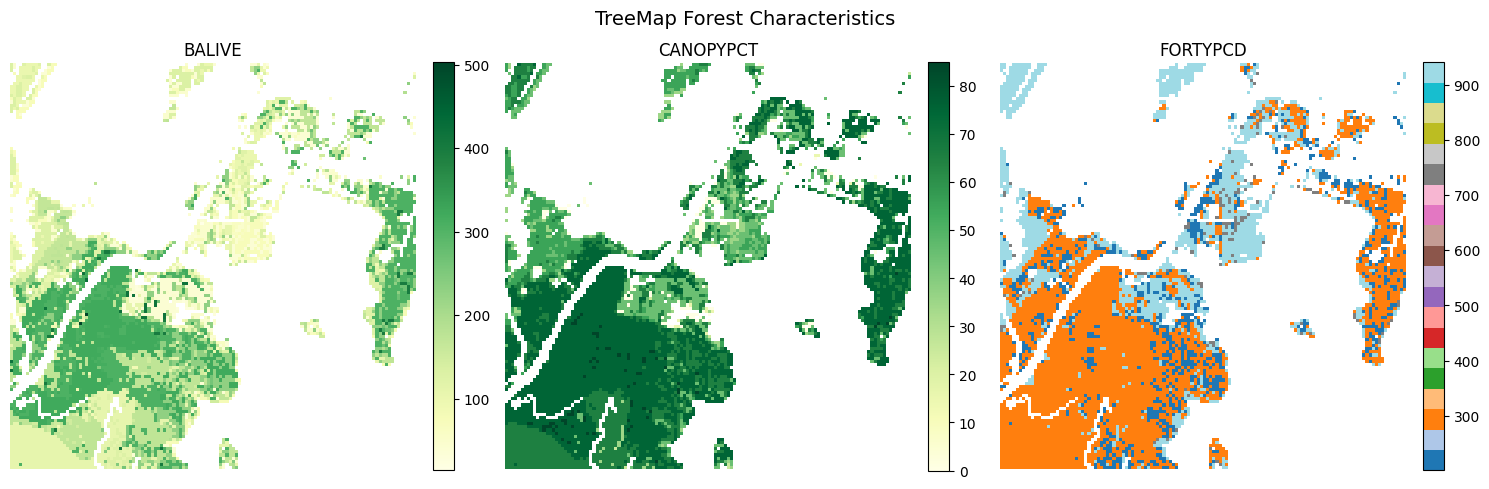

In [9]:
# Visualize individual bands

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cmap = 'YlGn'
for idx, (band_name, ax) in enumerate(zip(treemap.bands, axes)):
    if band_name == 'FORTYPCD':
        cmap = 'tab20'
    band_data = sample["mask"][idx].type(torch.float32).numpy()
    band_data[band_data < 0] = np.nan
    im = ax.imshow(band_data, cmap=cmap)
    ax.set_title(f'{band_name}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('TreeMap Forest Characteristics', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Examine Forest Characteristics

Let's analyze the distribution of forest characteristics in our ROI.

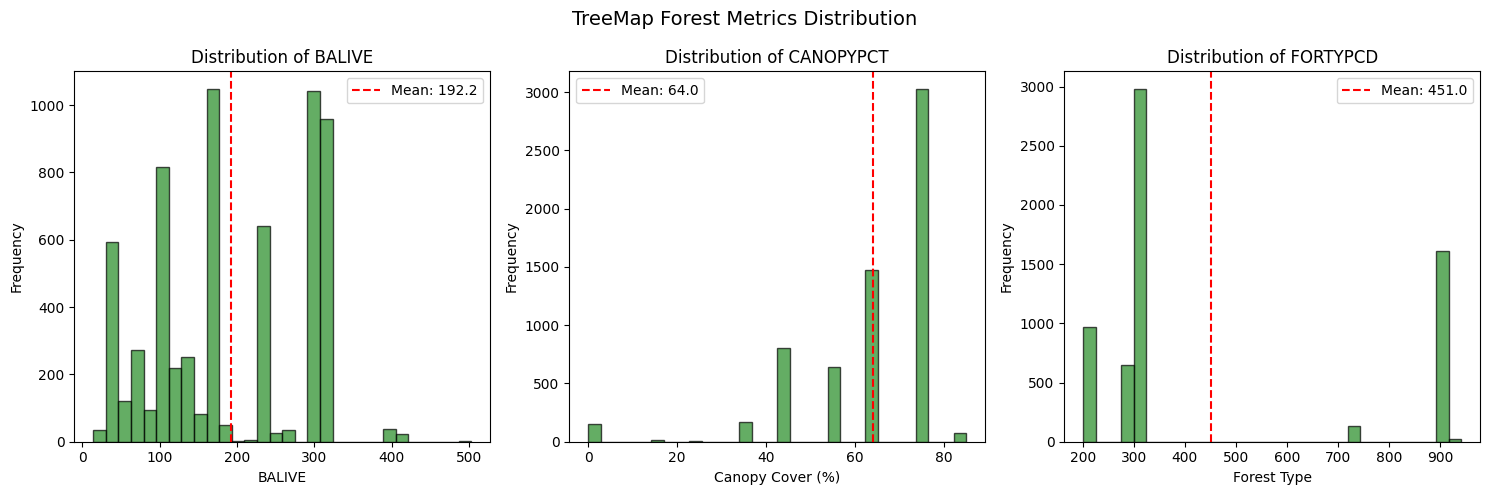

In [8]:
metrics = [
    ("BALIVE", "BALIVE"),
    ("CANOPYPCT", "Canopy Cover (%)"),
    ("FORTYPCD", "Forest Type"),
]

# Override 2x2 to fit 5 metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax in axes.flat[len(metrics):]:
    ax.axis("off")

for (band_name, label), ax in zip(metrics, axes.flat):
    band_idx = treemap.bands.index(band_name)
    data = sample["mask"][band_idx]
    data = data[data > treemap.nodata].numpy().flatten()
    
    ax.hist(data, bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {band_name}')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.legend()

plt.suptitle('TreeMap Forest Metrics Distribution', fontsize=14)
plt.tight_layout()
plt.show()